### 1. 載入函示庫與資料

In [76]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import psycopg2
from datetime import datetime

# 顯示更完整的輸出
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✓ 導入完成")

✓ 導入完成


In [77]:
# 資料庫連接設定
# Docker Compose 已將 PostgreSQL 映射到 localhost:5432
DB_USER = "admin"
DB_PASSWORD = "password123"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "anime_warehouse"

# 建立連接字串
db_url = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

try:
    engine = create_engine(db_url, pool_pre_ping=True)
    
    # 測試連接
    with engine.connect() as conn:
        result = conn.execute(text("SELECT 1"))
        conn.commit()
    
    print(f"✓ 資料庫連接成功")
    print(f"  主機: {DB_HOST}:{DB_PORT}")
    print(f"  資料庫: {DB_NAME}")
    print(f"  用戶: {DB_USER}")
    
except Exception as e:
    print(f"✗ 連接失敗: {e}")
    print("\n💡 提示:")
    print("  確保 Docker Compose 正在運行: docker compose up -d")
    raise

✓ 資料庫連接成功
  主機: localhost:5432
  資料庫: anime_warehouse
  用戶: admin


In [78]:
# 讀取兩個數據來源

# 1. 讀取乾淨的動畫列表視圖
print("讀取 v_clean_tv_animelist 視圖...")
query_view = """
SELECT * FROM public.v_clean_tv_animelist
LIMIT 5
"""
df_animelist = pd.read_sql_query(query_view, engine)
print(f"✓ 視圖讀取成功: {len(df_animelist)} 筆記錄（顯示前 5 筆）")
print(f"  欄位: {list(df_animelist.columns)}")
print()

# 2. 讀取動畫元數據表
print("讀取 anime_metadata 資料表...")
query_metadata = """
SELECT * FROM public.anime_metadata
LIMIT 5
"""
df_metadata = pd.read_sql_query(query_metadata, engine)
print(f"✓ 表格讀取成功: {len(df_metadata)} 筆記錄（顯示前 5 筆）")
print(f"  欄位: {list(df_metadata.columns)}")
print()

print("=" * 60)
print("完整的統計信息")
print("=" * 60)

# 獲取完整資料筆數
with engine.connect() as conn:
    result_view = conn.execute(text("SELECT COUNT(*) as count FROM public.v_clean_tv_animelist"))
    count_view = result_view.fetchone()[0]
    
    result_metadata = conn.execute(text("SELECT COUNT(*) as count FROM public.anime_metadata"))
    count_metadata = result_metadata.fetchone()[0]
    conn.commit()

print(f"v_clean_tv_animelist 視圖: {count_view:,} 筆動畫")
print(f"anime_metadata 表格: {count_metadata:,} 筆元數據")

讀取 v_clean_tv_animelist 視圖...
✓ 視圖讀取成功: 5 筆記錄（顯示前 5 筆）
  欄位: ['title', 'episodes', 'rating', 'mean_view_count', 'sum_view_count', 'churn_rate', 'frequency', 'aired_weekly', 'type', 'year', 'season', 'first_pub_date', 'last_pub_date', 'r18', 'url']

讀取 anime_metadata 資料表...
✓ 表格讀取成功: 5 筆記錄（顯示前 5 筆）
  欄位: ['title', 'url', 'agent', 'studio', 'tags', 'updated_at']

完整的統計信息
v_clean_tv_animelist 視圖: 1,362 筆動畫
anime_metadata 表格: 1,362 筆元數據


In [79]:
# 加載完整數據集用於機器學習

print("加載完整數據集...")

# 加載 v_clean_tv_animelist 視圖
df_animelist_full = pd.read_sql_query("SELECT * FROM public.v_clean_tv_animelist", engine)
print(f"✓ v_clean_tv_animelist: {df_animelist_full.shape[0]} 筆 × {df_animelist_full.shape[1]} 欄")

# 加載 anime_metadata 表格
df_metadata_full = pd.read_sql_query("SELECT * FROM public.anime_metadata", engine)
print(f"✓ anime_metadata: {df_metadata_full.shape[0]} 筆 × {df_metadata_full.shape[1]} 欄")

# 資料類型
print("\n【v_clean_tv_animelist 數據類型】")
print(df_animelist_full.dtypes)

print("\n【anime_metadata 數據類型】")
print(df_metadata_full.dtypes)

# 缺失值檢查
print("\n【v_clean_tv_animelist 缺失值】")
print(df_animelist_full.isnull().sum())

print("\n【anime_metadata 缺失值】")
print(df_metadata_full.isnull().sum())

加載完整數據集...
✓ v_clean_tv_animelist: 1362 筆 × 15 欄
✓ anime_metadata: 1362 筆 × 6 欄

【v_clean_tv_animelist 數據類型】
title                              str
episodes                         int64
rating                         float64
mean_view_count                float64
sum_view_count                 float64
churn_rate                         str
frequency                          str
aired_weekly                      bool
type                               str
year                           float64
season                             str
first_pub_date     datetime64[us, UTC]
last_pub_date      datetime64[us, UTC]
r18                               bool
url                                str
dtype: object

【anime_metadata 數據類型】
title                    str
url                      str
agent                    str
studio                   str
tags                  object
updated_at    datetime64[us]
dtype: object

【v_clean_tv_animelist 缺失值】
title                0
episodes             0
rating 

### 2.資料彙整與前處理

In [80]:
# 合併資料
df = pd.merge(df_animelist_full, df_metadata_full, on='title', how='inner')
print(f"\n✓ 合併完成: {df.shape[0]} 筆 × {df.shape[1]} 欄")
print(df.head())


✓ 合併完成: 1362 筆 × 20 欄
                           title  episodes  rating  mean_view_count  \
0                 鬼滅之刃 竈門炭治郎 立志篇        26     4.9        1267134.0   
1  進擊的巨人 The Final Season 完結篇 後篇         1     5.0        1220530.0   
2                       鬼滅之刃 遊郭篇        11     4.9        1086712.0   
3  進擊的巨人 The Final Season 完結篇 前篇         1     5.0        1037448.0   
4                           咒術迴戰        24     4.9        1000479.0   

   sum_view_count churn_rate frequency  aired_weekly  type    year season  \
0      32945484.0      33.6%    weekly          True   半年番  2019.0     春番   
1       1220530.0        N/A    weekly         False  短篇動畫     NaN    NaN   
2      11953832.0      22.7%    weekly          True    季番  2021.0     秋番   
3       1037448.0        N/A    weekly         False  短篇動畫     NaN    NaN   
4      24011486.0      37.8%    weekly          True   半年番  2020.0     秋番   

             first_pub_date             last_pub_date    r18  \
0 2019-04-06 16:00:00+0

In [81]:
# 整理資料：使用 type（不使用 episodes）
type_col = next((c for c in ['type', 'type_x', 'type_y'] if c in df.columns), None)
if type_col is None:
    raise KeyError("找不到 type 欄位（type/type_x/type_y）")

df = df[['title', type_col, 'rating', 'churn_rate', 'mean_view_count', 'tags', 'r18']].copy()
df.rename(columns={type_col: 'type'}, inplace=True)

df.replace(['N/A', 'n/a', 'nan', 'None', ''], np.nan, inplace=True)
df.dropna(subset=['churn_rate', 'type'], inplace=True)
df['churn_rate'] = df['churn_rate'].astype(str).str.strip('%').astype(float) / 100

df.head()

,title,type,rating,churn_rate,mean_view_count,tags,r18
0,鬼滅之刃 竈門炭治郎 立志篇,半年番,4.9,0.336,1267134.0,"[動作, 冒險, 奇幻, 血腥暴力]",False
2,鬼滅之刃 遊郭篇,季番,4.9,0.227,1086712.0,"[動作, 冒險, 奇幻, 血腥暴力]",False
4,咒術迴戰,半年番,4.9,0.378,1000479.0,"[動作, 奇幻, 超能力, 校園, 血腥暴力, 靈異神怪]",False
5,輝夜姬想讓人告白～天才們的戀愛頭腦戰～,季番,4.9,0.370,853700.0,"[校園, 喜劇, 戀愛]",False
6,輝夜姬想讓人告白～天才們的戀愛頭腦戰～ 第二季,季番,5.0,0.270,833028.0,"[校園, 喜劇, 戀愛]",False


<Axes: >

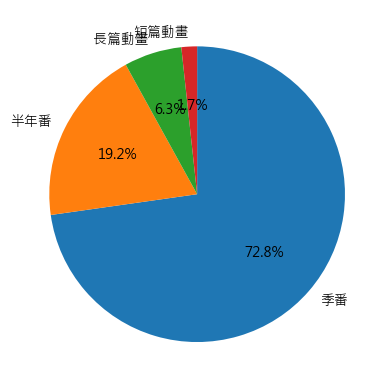

In [82]:
df.type.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)

In [83]:
import json

df['tags'] = df['tags'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
tags_one_hot = df['tags'].str.join('|').str.get_dummies()
type_order = ['短篇動畫', '季番', '半年番', '長篇動畫']
unknown = sorted(set(df['type'].dropna().unique()) - set(type_order))
if unknown:
    raise ValueError(f"type 欄位有未定義類別: {unknown}")
df['type'] = pd.Categorical(df['type'], categories=type_order, ordered=True)
df['type_ord'] = df['type'].cat.codes  # 0,1,2,3
df_merged = pd.concat([df.drop(columns=['tags', 'type']), tags_one_hot], axis=1)
df_merged.set_index('title', inplace=True)
df_merged['r18'] = df_merged['r18'].astype(int)

print("type 有序編碼完成：", dict(enumerate(type_order)))

type 有序編碼完成： {0: '短篇動畫', 1: '季番', 2: '半年番', 3: '長篇動畫'}


In [84]:
df_merged = df_merged[df_merged['真人演出'] == 0]
df_merged.drop('真人演出', axis=1, inplace=True)

### 3. 描述統計量

In [85]:
df_merged.describe()

,rating,churn_rate,mean_view_count,r18,type_ord,BL,GL,偶像,冒險,動作,勵志,喜劇,奇幻,悠閒,感人,懸疑,戀愛,戰爭,推理,料理,時間穿越,校園,機甲,歷史,泡麵番,溫馨,特攝,異世界,科幻,競技,職場,血腥暴力,親情,超能力,運動,闔家觀賞,靈異神怪,青春,音樂,魔法,黑暗
count,1310.000000,1310.000000,1.310000e+03,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000
mean,4.585344,0.545335,1.025984e+05,0.010687,1.281679,0.008397,0.007634,0.038168,0.300763,0.244275,0.123664,0.265649,0.343511,0.072519,0.023664,0.061069,0.207634,0.037405,0.041221,0.026718,0.016794,0.254962,0.026718,0.019084,0.055725,0.117557,0.004580,0.111450,0.100763,0.074046,0.064122,0.060305,0.029771,0.067176,0.070229,0.078626,0.070992,0.148855,0.054962,0.151908,0.051145
std,0.458731,0.171262,1.379070e+05,0.102863,0.580469,0.091284,0.087070,0.191675,0.458765,0.429820,0.329324,0.441847,0.475062,0.259445,0.152058,0.239548,0.405768,0.189824,0.198878,0.161318,0.128548,0.436006,0.161318,0.136872,0.229478,0.322206,0.067547,0.314809,0.301130,0.261945,0.245064,0.238143,0.170020,0.250421,0.255630,0.269257,0.256910,0.356081,0.227993,0.359069,0.220378
min,1.500000,0.102000,9.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.500000,0.420250,1.822100e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.700000,0.542500,5.577350e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.900000,0.663750,1.318858e+05,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,0.986000,1.267134e+06,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [86]:
len(df_merged.columns)

41

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']

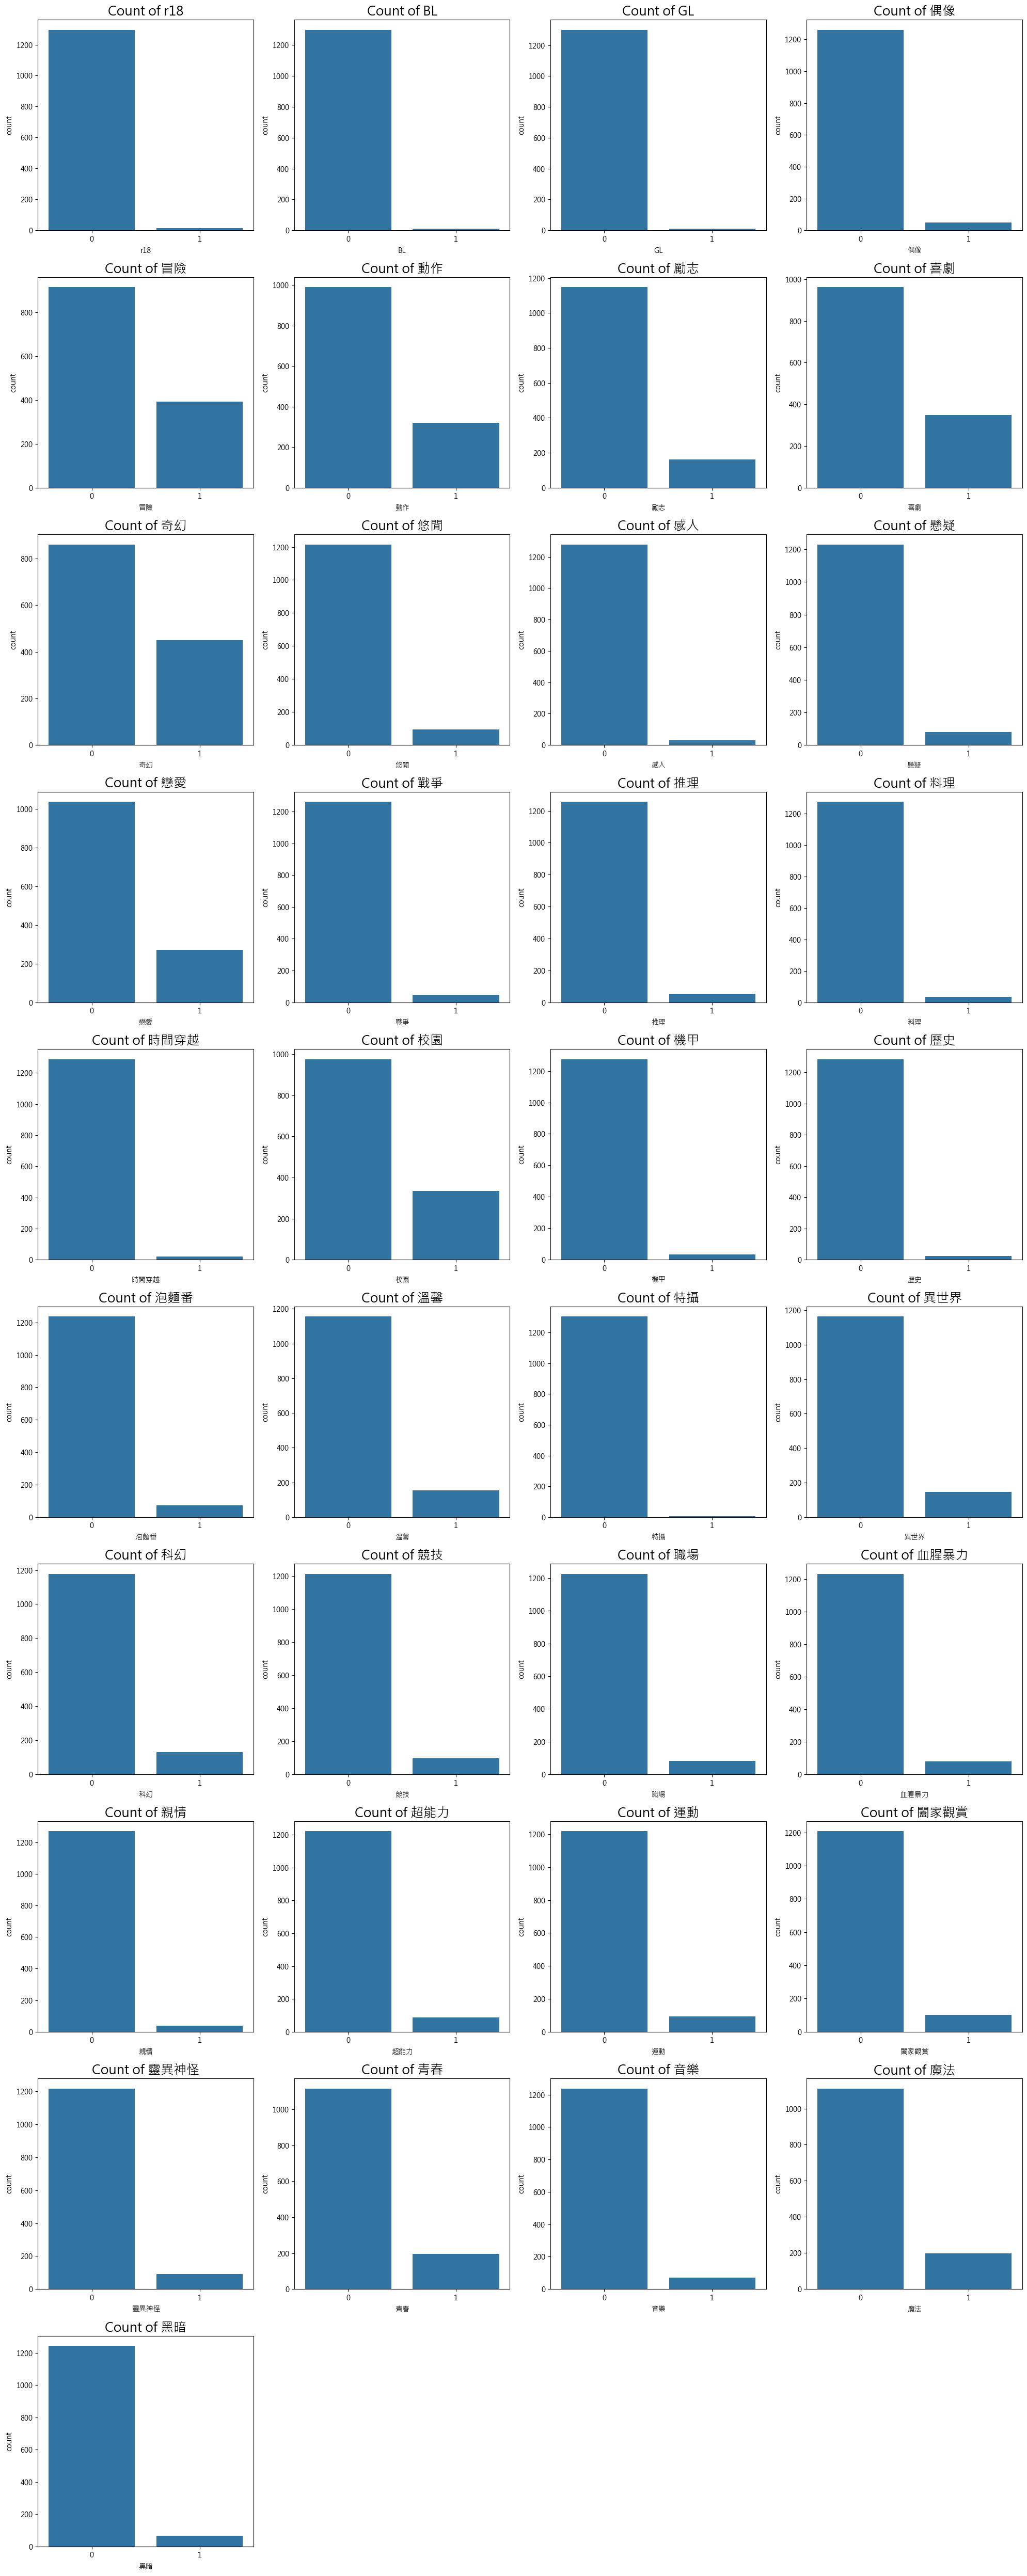

In [88]:
cols_to_plot = ['r18', 'BL','GL', '偶像', '冒險', '動作', '勵志', '喜劇', '奇幻', '悠閒',
                '感人', '懸疑', '戀愛', '戰爭','推理', '料理', '時間穿越', '校園', '機甲',
                '歷史', '泡麵番', '溫馨', '特攝', '異世界', '科幻', '競技', '職場',
                '血腥暴力', '親情', '超能力', '運動', '闔家觀賞', '靈異神怪', '青春', '音樂',
                '魔法', '黑暗']

fig, axes = plt.subplots(10, 4, figsize=(20, 50))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):

    sns.countplot(data=df_merged, x=col, ax=axes[i])
    axes[i].set_title(f'Count of {col}',fontdict={'fontsize': 18})

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout() 
plt.show()

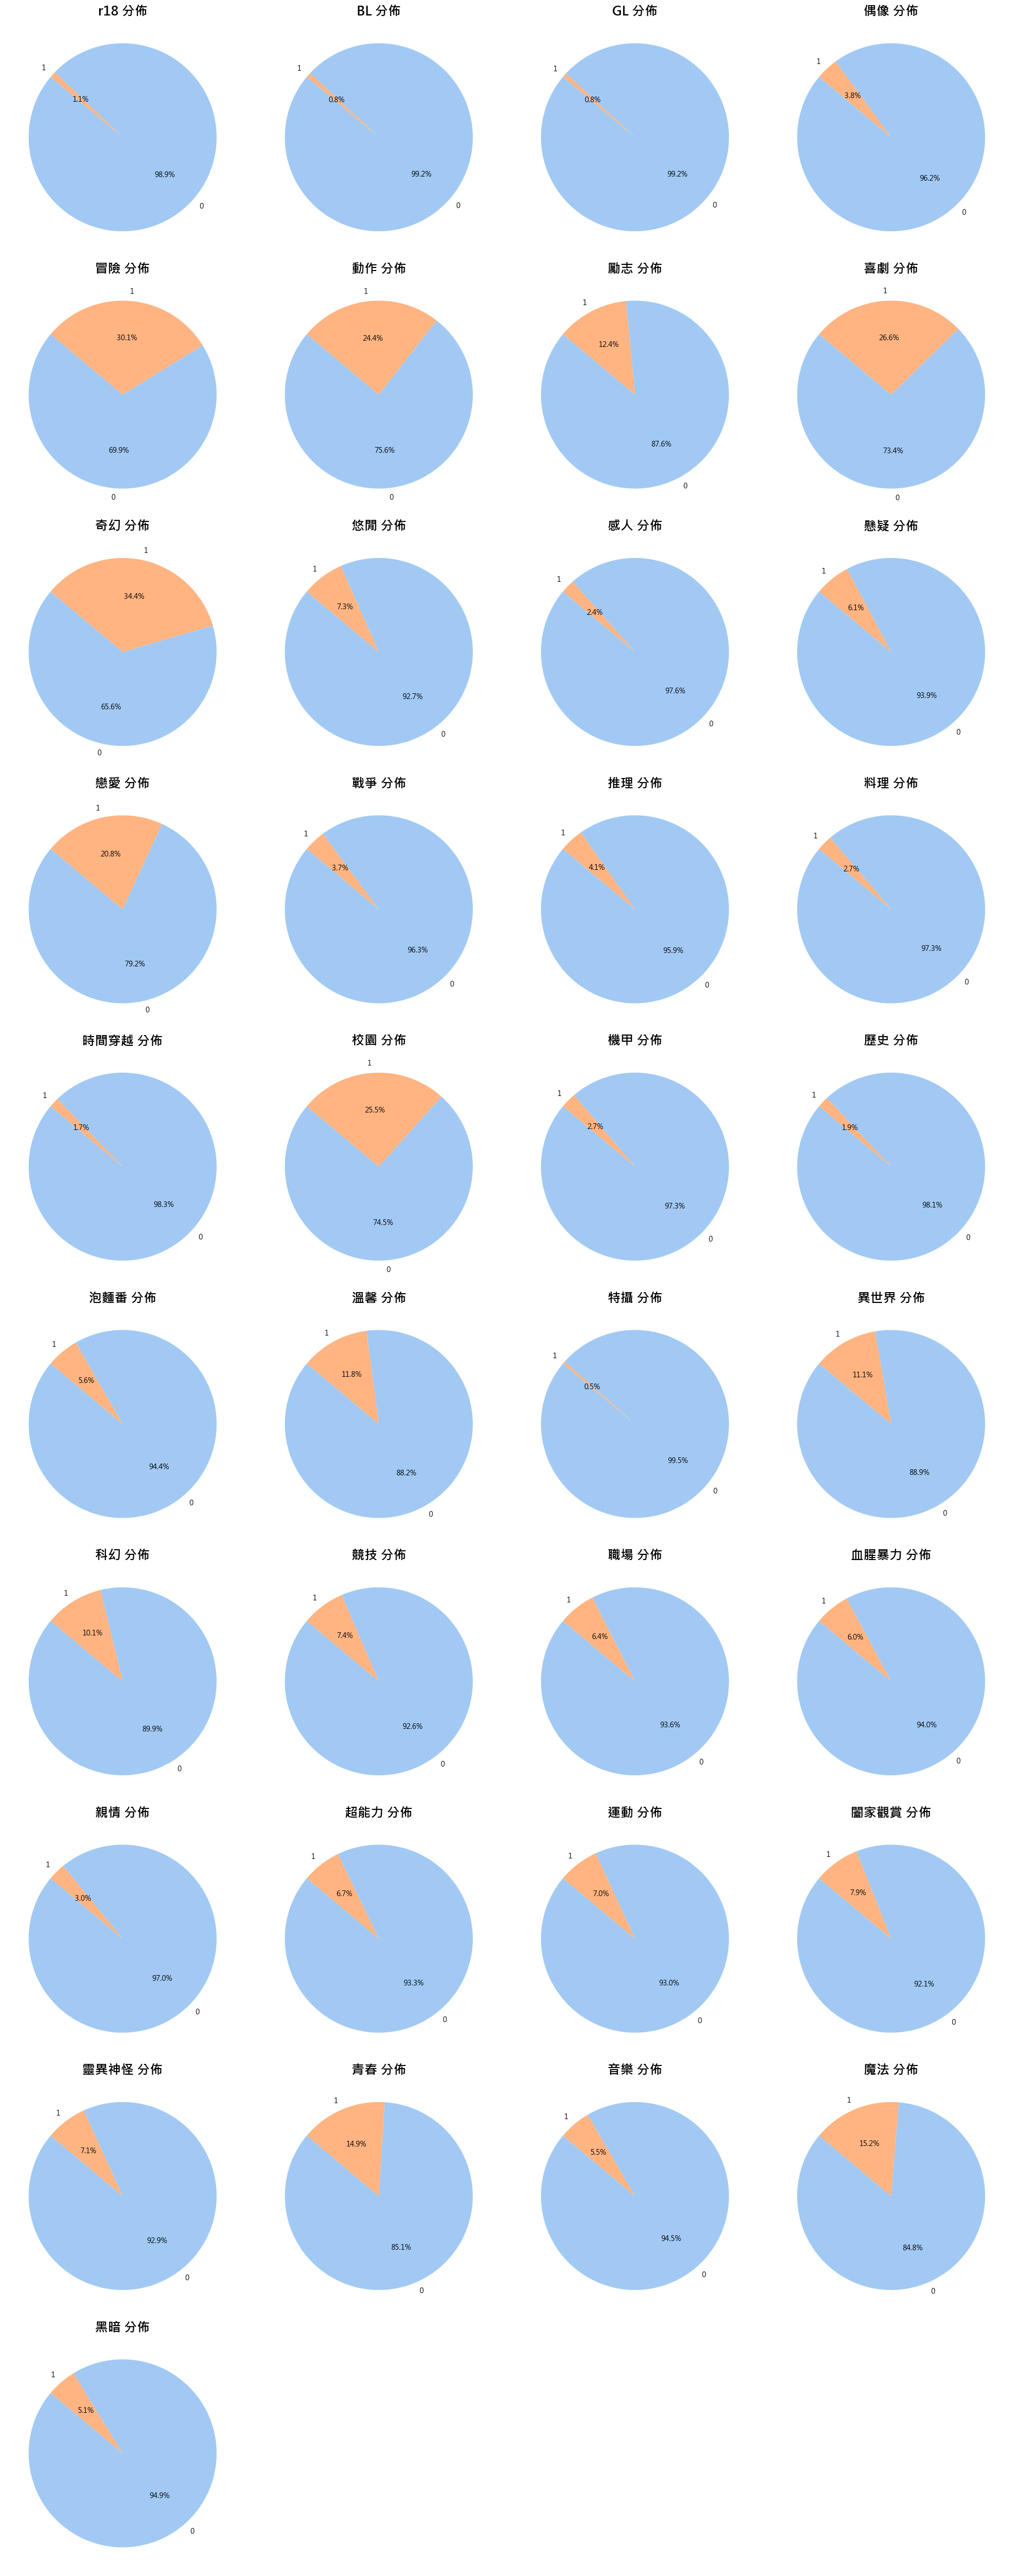

In [89]:
fig, axes = plt.subplots(10, 4, figsize=(20, 50))
axes = axes.flatten()
colors = sns.color_palette('pastel')

for i, col in enumerate(cols_to_plot):
    counts = df_merged[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', 
                startangle=140, colors=colors)
    axes[i].set_title(f'{col} 分佈', fontdict={'fontsize': 18, 'fontweight': 'bold'})
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [368]:
print(df_merged[(df_merged['競技']==1) & (df_merged['運動']!=1)].index)
print(df_merged[(df_merged['競技']==1) & (df_merged['運動']!=1)].shape[0])
print("---------------")
print(df_merged[(df_merged['競技']==0) & (df_merged['運動']==1)].index)
print(df_merged[(df_merged['競技']==0) & (df_merged['運動']==1)].shape[0])

Index(['龍王的工作！', '急戰 5 秒殊死鬥', '3 月的獅子', '一弦定音！', '一弦定音！第二季', '3 月的獅子 第二季',
       '謊言遊戲', '靠死亡遊戲混飯吃。', '花牌情緣', '花牌情緣 第三季', '花牌情緣 第二季', '天晴爛漫！', '真白之音',
       '棋靈王', '神明渴求著遊戲。', '中華一番', '碰之道', 'Paradox Live THE ANIMATION',
       '我們的雨色協議', 'BUILD-DIVIDE -#000000- CODE BLACK',
       '『催眠麥克風-Division Rap Battle-』Rhyme Anima +', '群青的開幕曲', '閃電霹靂車',
       'BUILD-DIVIDE -#FFFFFF- CODE WHITE', '涅庫羅諾美子的宇宙恐怖秀', '賭博默示錄',
       '遊戲王! SEVENS', '賭博默示錄 破戒錄篇'],
      dtype='str', name='title')
28
---------------
Index(['排球少年！！第四季 Part 2', '排球少年！！第四季', '排球少年！！', '排球少年！！第三季', '排球少年！！第二季',
       '流汗吧！健身少女', '高校之神', 'GRAND BLUE 碧藍之海 2', '籃球少年王', 'GRAND BLUE 碧藍之海',
       '白領羽球部', '飆速宅男 第二季', '飆速宅男', '隊長小翼', '精靈小姐瘦不了', '飆速宅男 第三季', '美妙射擊部',
       '男子啦啦隊！！', '飆速宅男 第四季', 'TRIBE NINE', '飆速宅男 第五季', '橘色榮耀！',
       'WAVE!! ~來衝浪吧!!~'],
      dtype='str', name='title')
23


<Axes: xlabel='churn_rate', ylabel='Count'>

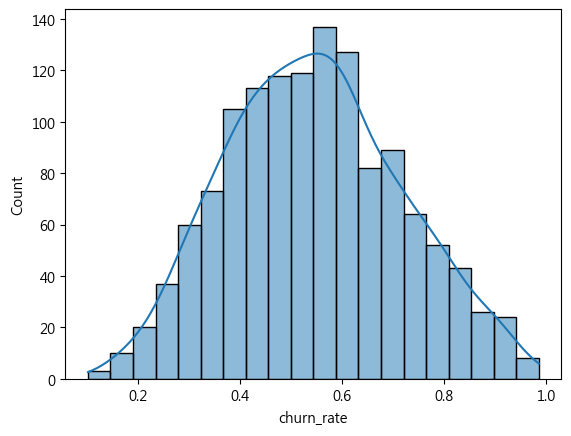

In [90]:
sns.histplot(df_merged['churn_rate'], bins=20, kde=True)

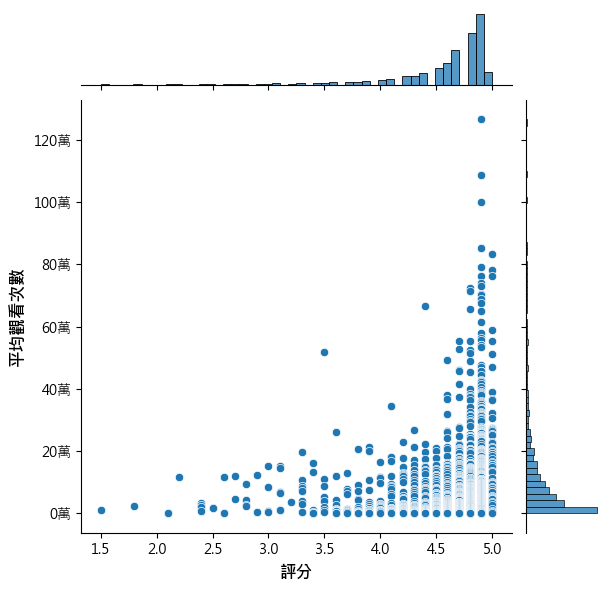

In [91]:
import matplotlib.ticker as ticker

g = sns.jointplot(data=df_merged, x='rating', y='mean_view_count', kind='scatter')
g.ax_joint.set_xlabel('評分', fontdict={'fontsize': 12, 'fontweight': 'bold'})
g.ax_joint.set_ylabel('平均觀看次數', fontdict={'fontsize': 12, 'fontweight': 'bold'})
g.ax_joint.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e4:g}萬'))


In [92]:
df_merged.describe()

,rating,churn_rate,mean_view_count,r18,type_ord,BL,GL,偶像,冒險,動作,勵志,喜劇,奇幻,悠閒,感人,懸疑,戀愛,戰爭,推理,料理,時間穿越,校園,機甲,歷史,泡麵番,溫馨,特攝,異世界,科幻,競技,職場,血腥暴力,親情,超能力,運動,闔家觀賞,靈異神怪,青春,音樂,魔法,黑暗
count,1310.000000,1310.000000,1.310000e+03,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000
mean,4.585344,0.545335,1.025984e+05,0.010687,1.281679,0.008397,0.007634,0.038168,0.300763,0.244275,0.123664,0.265649,0.343511,0.072519,0.023664,0.061069,0.207634,0.037405,0.041221,0.026718,0.016794,0.254962,0.026718,0.019084,0.055725,0.117557,0.004580,0.111450,0.100763,0.074046,0.064122,0.060305,0.029771,0.067176,0.070229,0.078626,0.070992,0.148855,0.054962,0.151908,0.051145
std,0.458731,0.171262,1.379070e+05,0.102863,0.580469,0.091284,0.087070,0.191675,0.458765,0.429820,0.329324,0.441847,0.475062,0.259445,0.152058,0.239548,0.405768,0.189824,0.198878,0.161318,0.128548,0.436006,0.161318,0.136872,0.229478,0.322206,0.067547,0.314809,0.301130,0.261945,0.245064,0.238143,0.170020,0.250421,0.255630,0.269257,0.256910,0.356081,0.227993,0.359069,0.220378
min,1.500000,0.102000,9.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.500000,0.420250,1.822100e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.700000,0.542500,5.577350e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.900000,0.663750,1.318858e+05,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,0.986000,1.267134e+06,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


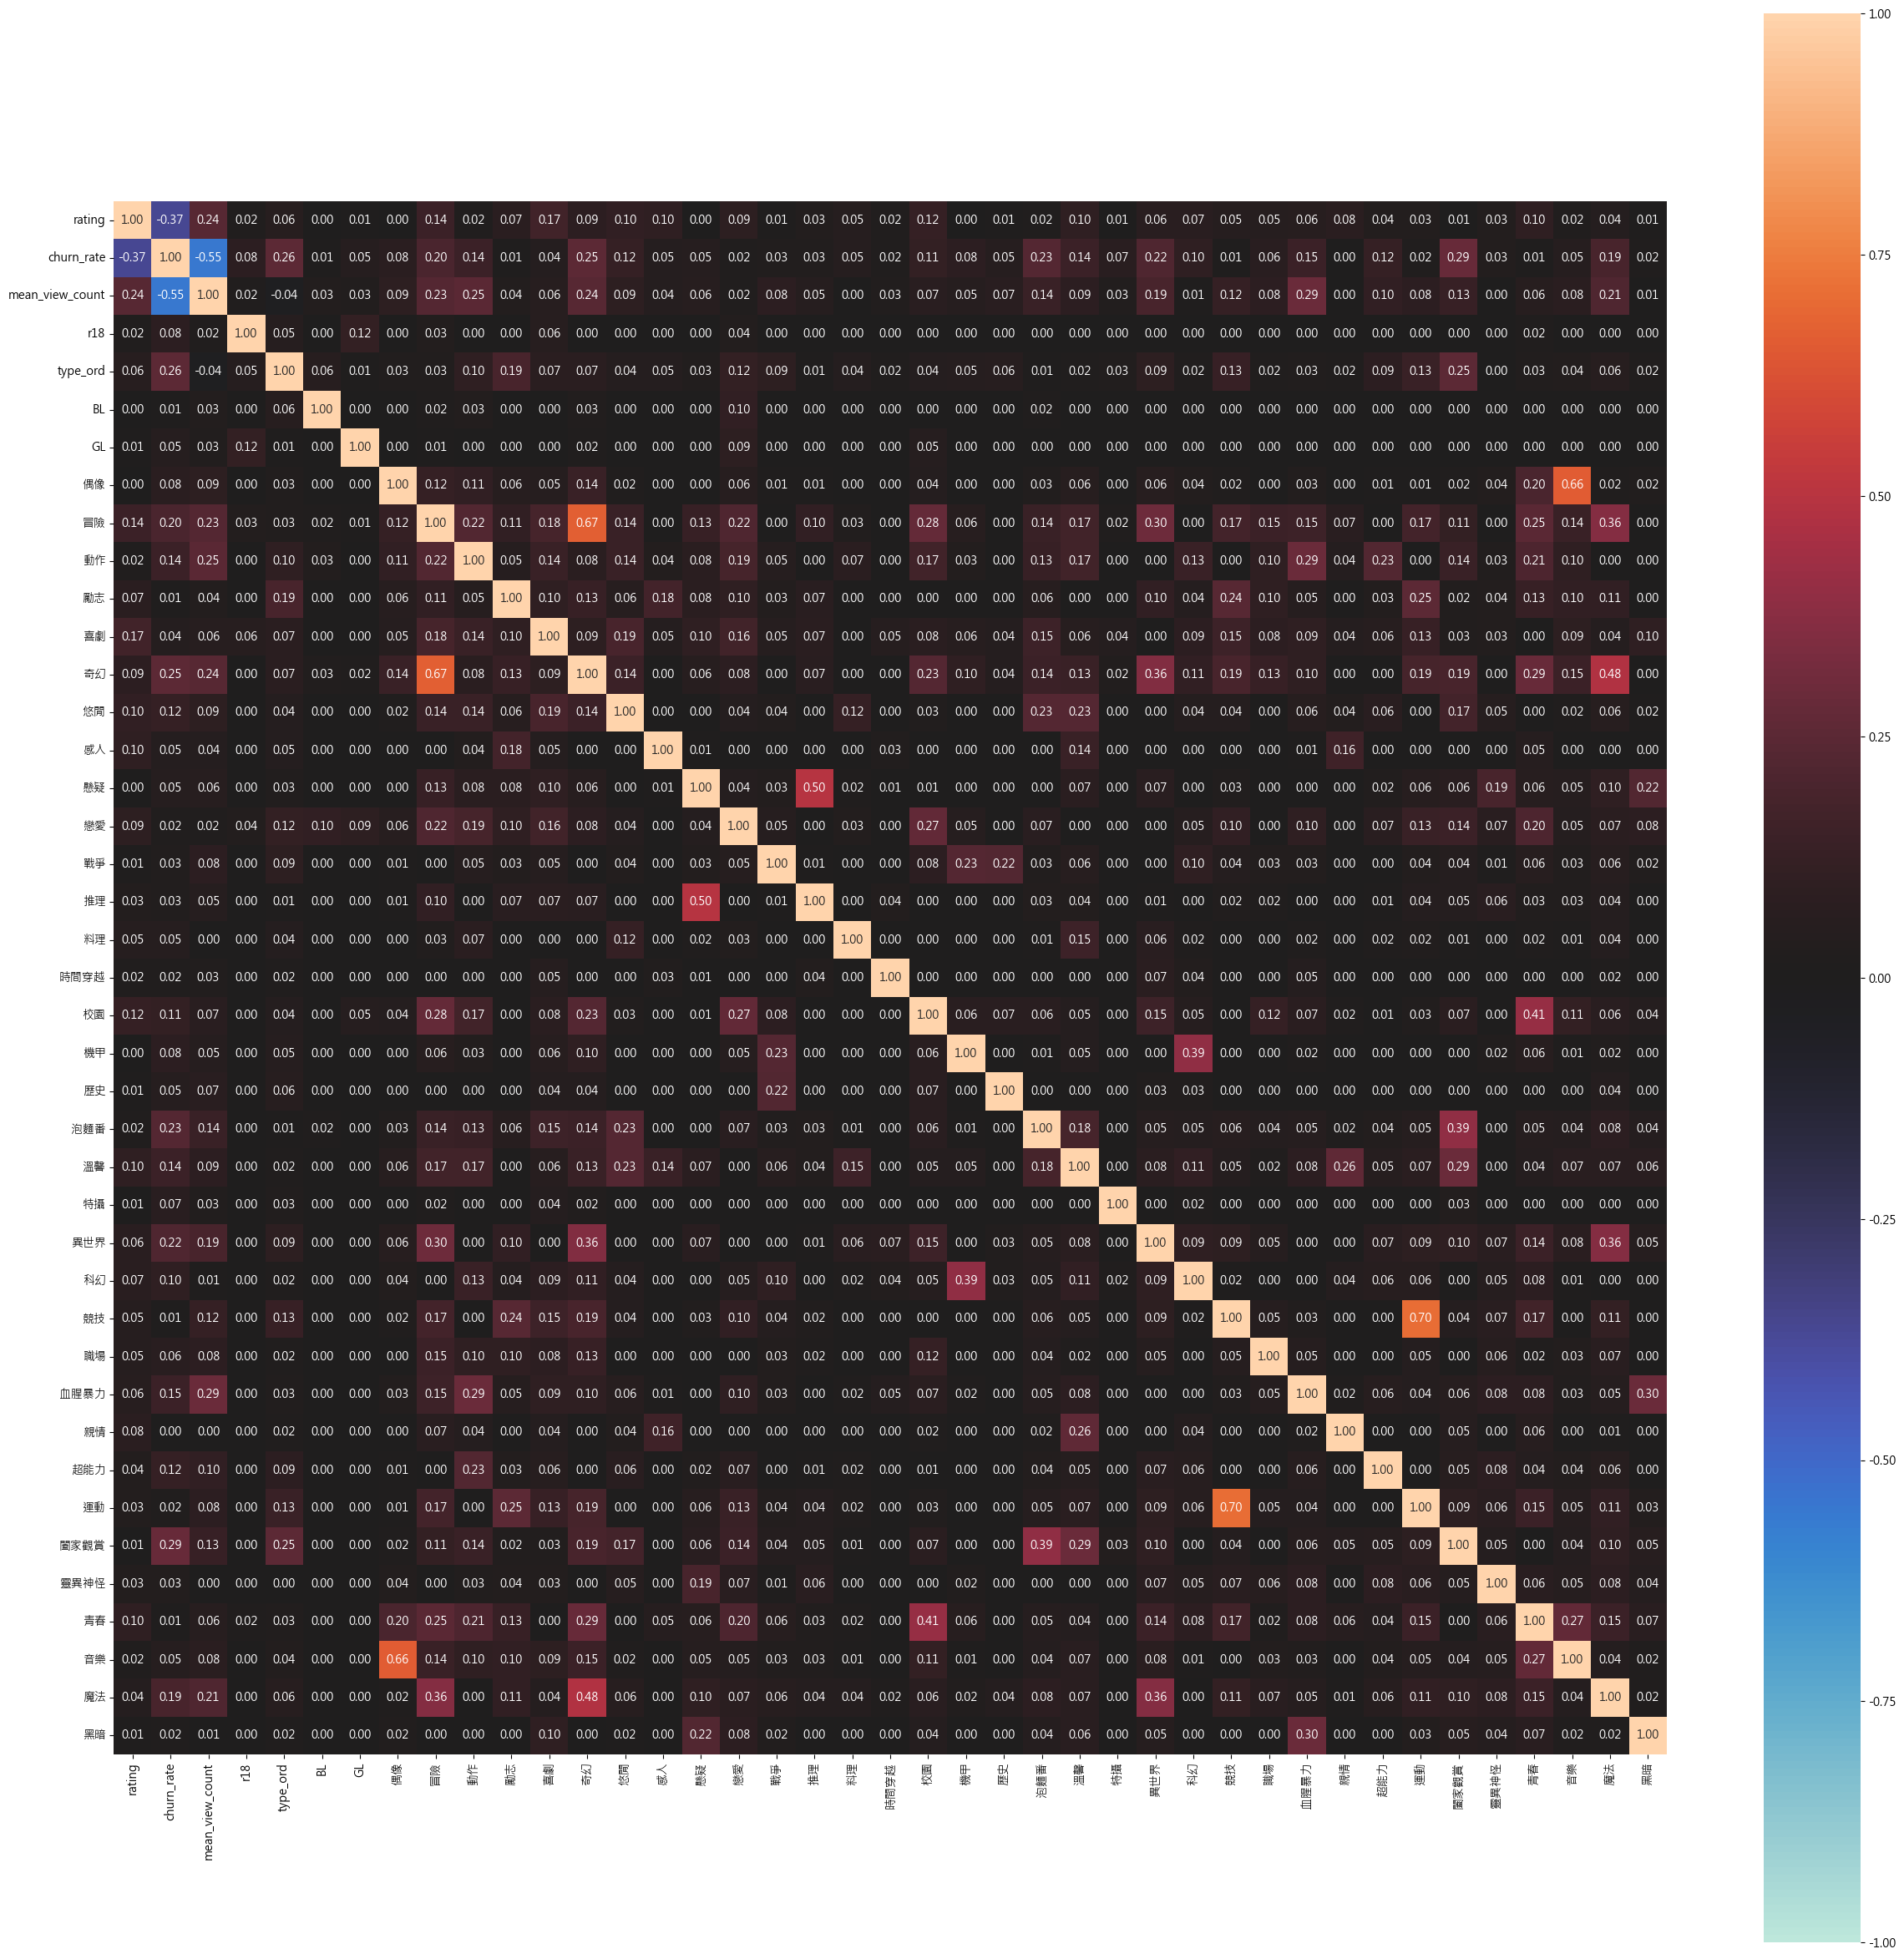

In [93]:
from dython.nominal import associations
results = associations(df_merged, 
                       nominal_columns=cols_to_plot,
                       figsize=(30, 30))
theils_u_matrix = results['corr']


In [362]:
df_merged.shape

(1310, 41)

In [369]:
# 找出所有標籤欄位中，出現次數（值為1）少於 40 次的特徵
threshold = 50
low_variance_cols = [col for col in tag_cols if df_merged[col].sum() < threshold]
low_variance_cols.append('運動') # 競技和運動高相關性，且非競技類的作品運動也不是作品主軸
print(f"預計刪除的稀疏特徵：{low_variance_cols}")

預計刪除的稀疏特徵：['r18', 'BL', 'GL', '感人', '戰爭', '料理', '時間穿越', '機甲', '歷史', '特攝', '親情', '運動']


In [381]:
# 執行刪除
df_ml_clean = df_merged.drop(columns=low_variance_cols)
cols = [c for c in cols_to_plot if c not in low_variance_cols]
df_ml_clean.shape

(1310, 29)

### 4.特徵工程

##### 對連續屬性做變數變換與標準化

In [494]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
scaler = StandardScaler()
pt = PowerTransformer(method='box-cox', standardize=True)
df_transformed = df_ml_clean.copy()
df_transformed['mean_view_count'] = np.log10(df_transformed['mean_view_count'])
df_transformed['rating'] = pt.fit_transform(df_transformed[['rating']])
df_transformed['churn_rate'] = scaler.fit_transform(df_transformed[['churn_rate']])
df_transformed['mean_view_count'] = scaler.fit_transform(df_transformed[['mean_view_count']])

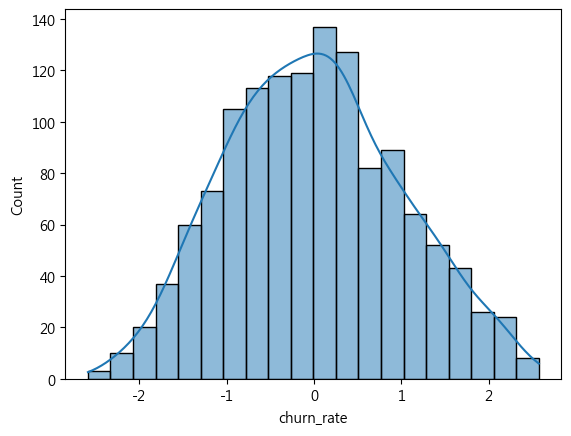

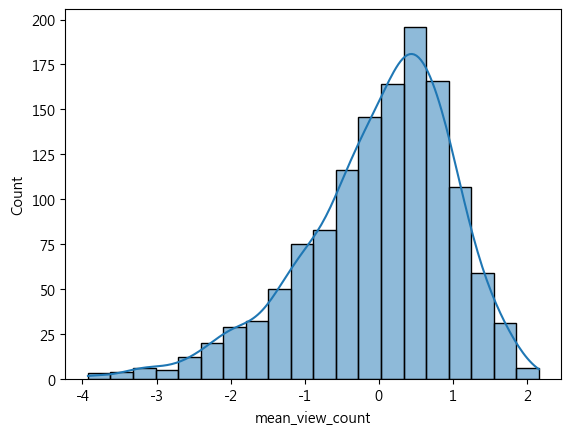

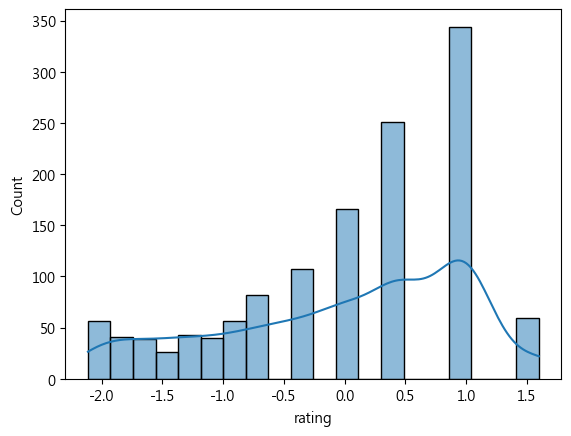

In [495]:
plt.rcParams['axes.unicode_minus'] = False
sns.histplot(df_transformed['churn_rate'], bins=20, kde=True)
plt.show()
sns.histplot(df_transformed['mean_view_count'], bins=20, kde=True)
plt.show()
sns.histplot(df_transformed['rating'], bins=20, kde=True)
plt.show()

##### 給類別變數加權

In [496]:
for icol, col in enumerate(cols):
    df_transformed[col] = df_transformed[col]*0.5
df_transformed['type_ord'] = df_transformed['type_ord']*0.5

In [497]:
df_transformed.head()

,rating,churn_rate,mean_view_count,type_ord,偶像,冒險,動作,勵志,喜劇,奇幻,悠閒,懸疑,戀愛,推理,校園,泡麵番,溫馨,異世界,科幻,競技,職場,血腥暴力,超能力,闔家觀賞,靈異神怪,青春,音樂,魔法,黑暗
title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
鬼滅之刃 竈門炭治郎 立志篇,0.979587,-1.222777,2.160215,1.0,0.0,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
鬼滅之刃 遊郭篇,0.979587,-1.859473,2.062016,0.5,0.0,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
咒術迴戰,0.979587,-0.977445,2.009159,1.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.5,0.0,0.0,0.0,0.0
輝夜姬想讓人告白～天才們的戀愛頭腦戰～,0.979587,-1.024175,1.907730,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
輝夜姬想讓人告白～天才們的戀愛頭腦戰～ 第二季,1.598937,-1.608299,1.892059,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 5.降維

##### PCA

In [498]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_transformed)

# 觀察「累積解釋變異量」
import numpy as np
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
cumulative_variance
# 看看要幾個維度才能達到 80% 的解釋力？
# 如果需要 20 個，代表作品真的很獨特；如果只要 8 個，代表主題還是很集中的。

num_components_80 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"達到 80% 解釋力需要的主成分數量: {num_components_80}")

達到 80% 解釋力需要的主成分數量: 8


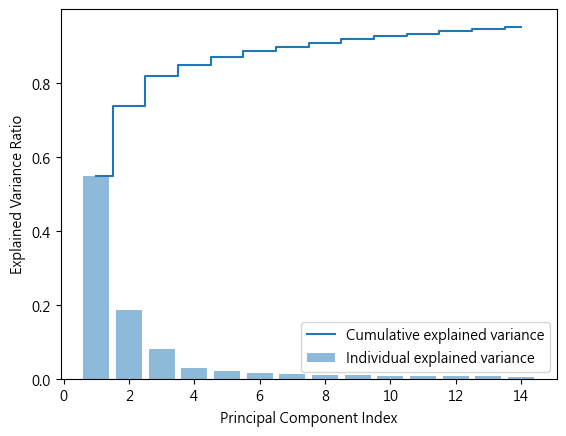

In [499]:
plt.bar(range(1, 15), pca.explained_variance_ratio_[:14], alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, 15), cumulative_variance[:14], where='mid', label='Cumulative explained variance')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.legend(loc='best')
plt.show()

In [500]:
X_pca = pca.fit_transform(df_transformed)[:, :3]
X_pca.shape

(1310, 3)

##### t-SNE

In [501]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

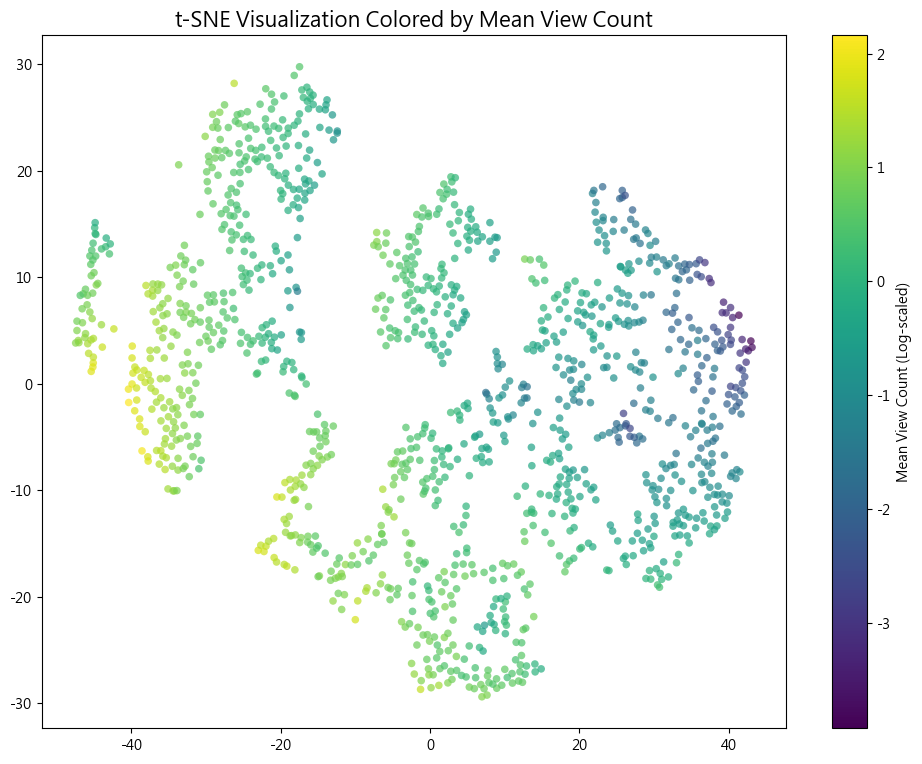

In [502]:
# ...existing code...
fig, ax = plt.subplots(figsize=(12, 9))

scatter = sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=df_transformed['mean_view_count'],
    palette='viridis',
    s=30,
    alpha=0.7,
    edgecolor='none',
    ax=ax
)

norm = plt.Normalize(df_transformed['mean_view_count'].min(), df_transformed['mean_view_count'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

if scatter.legend_ is not None:
    scatter.legend_.remove()

fig.colorbar(sm, ax=ax, label='Mean View Count (Log-scaled)')
ax.set_title('t-SNE Visualization Colored by Mean View Count', fontsize=15)
plt.show()
# ...existing code...

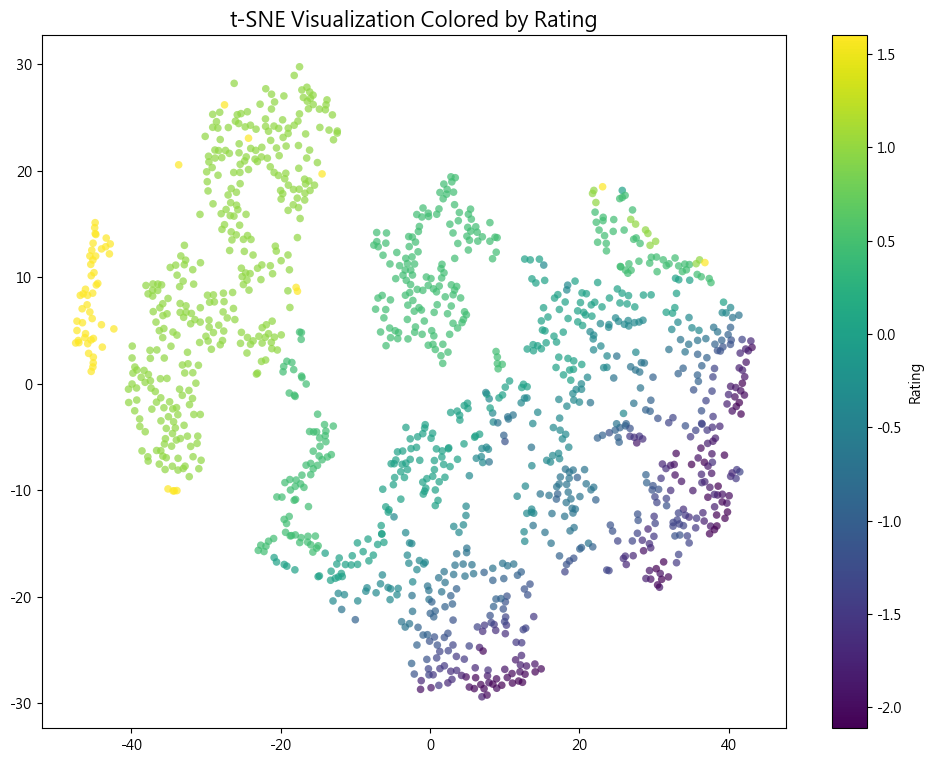

In [503]:
# ...existing code...
fig, ax = plt.subplots(figsize=(12, 9))

scatter = sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=df_transformed['rating'],
    palette='viridis',
    s=30,
    alpha=0.7,
    edgecolor='none',
    ax=ax
)

norm = plt.Normalize(df_transformed['rating'].min(), df_transformed['rating'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])

if scatter.legend_ is not None:
    scatter.legend_.remove()

fig.colorbar(sm, ax=ax, label='Rating')
ax.set_title('t-SNE Visualization Colored by Rating', fontsize=15)
plt.show()
# ...existing code...

Text(0.5, 1.0, 't-SNE Visualization of Anime Data')

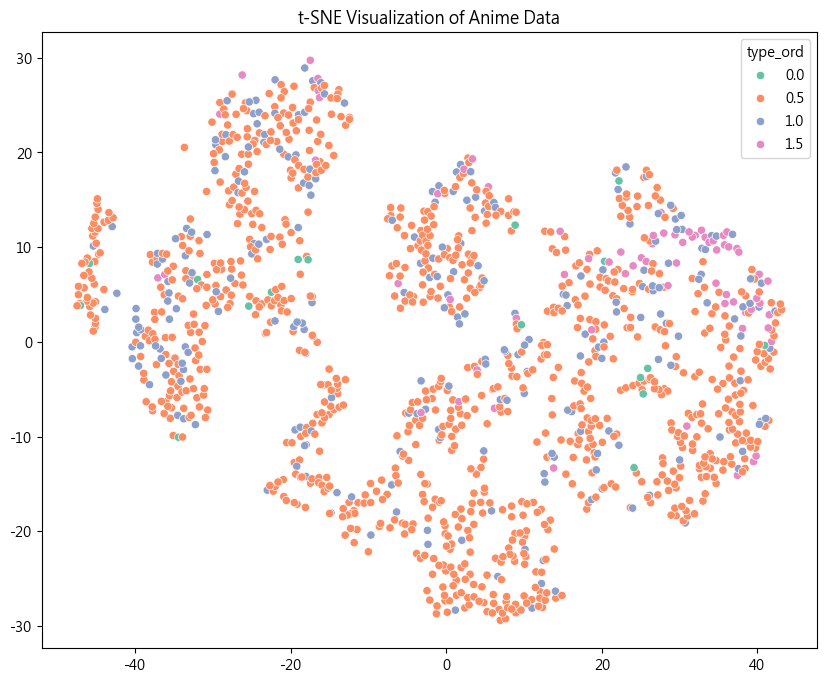

In [504]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_transformed['type_ord'], palette='Set2')
plt.title('t-SNE Visualization of Anime Data')

### 6.分群

##### HDBSCAN
    HDBSCAN 是一種基於密度的聚類算法，可以自動識別不同密度的群集，並且能夠處理噪聲數據。
第一個選擇使用它而非其他分群演算法的理由是這種基於密度的分群法更能捕捉到不規則形狀的群，
而HDBSCAN在邊界距離的調整上比起DBSCAN更加靈活。
以下是使用 HDBSCAN 進行聚類分析的示例代碼：

In [535]:
from sklearn.cluster import HDBSCAN

hdb = HDBSCAN(min_cluster_size=15, min_samples=2)
cluster_labels = hdb.fit_predict(X_pca)

df_clustered = df_transformed.copy()
df_clustered['cluster_labels'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"總共分出了 {n_clusters} 個動漫集群")
print(df_clustered['cluster_labels'].value_counts().sort_index())

總共分出了 10 個動漫集群
cluster_labels
-1    428
 0     47
 1    329
 2    214
 3     15
 4     45
 5     92
 6     26
 7     27
 8     68
 9     19
Name: count, dtype: int64


d:\Downloads\動畫瘋\AnimationDataProject\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Text(0.5, 1.0, 't-SNE Visualization of Anime Clusters grouped by HDBSCAN')

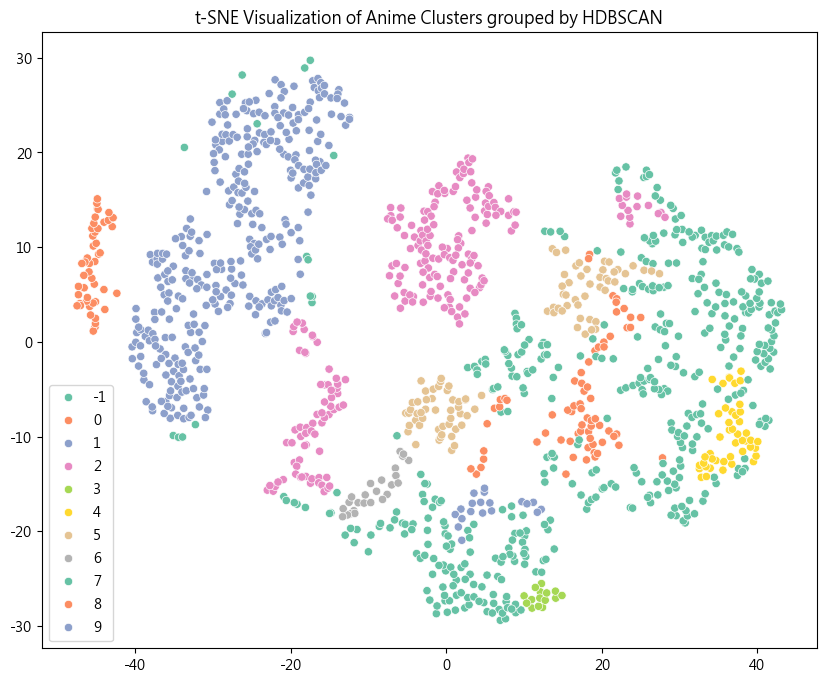

In [536]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=cluster_labels, palette='Set2')
plt.title('t-SNE Visualization of Anime Clusters grouped by HDBSCAN')

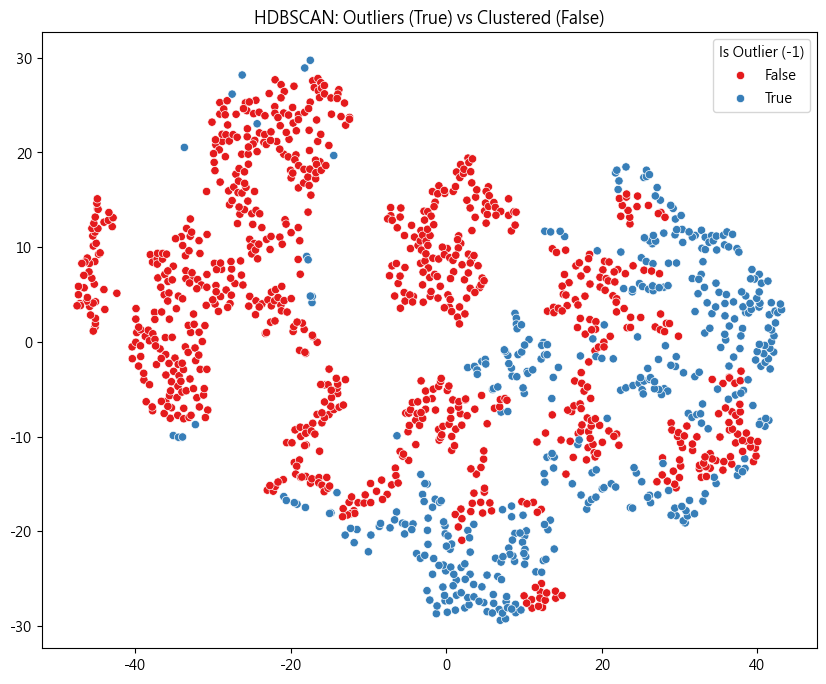

In [537]:
plt.figure(figsize=(10, 8))
# 判斷標籤是否為 -1
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=(cluster_labels == -1), 
    palette='Set1'
)
plt.title('HDBSCAN: Outliers (True) vs Clustered (False)')
plt.legend(title="Is Outlier (-1)")
plt.show()


In [538]:
df_clustered[df_clustered['cluster_labels'] == -1].sort_values(by='mean_view_count', ascending=False).head(10)

,rating,churn_rate,mean_view_count,type_ord,偶像,冒險,動作,勵志,喜劇,奇幻,悠閒,懸疑,戀愛,推理,校園,泡麵番,溫馨,異世界,科幻,競技,職場,血腥暴力,超能力,闔家觀賞,靈異神怪,青春,音樂,魔法,黑暗,cluster_labels
title,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
一拳超人 第二季,-0.943228,-1.672553,1.749502,0.5,0.0,0.0,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,-1
歡迎來到實力至上主義的教室,0.009327,-1.754331,1.629883,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,-1
魔王學院的不適任者～史上最強的魔王始祖，轉生就讀子孫們的學校～,0.009327,-1.269507,1.601720,0.5,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,-1
刀劍神域 Alicization War of Underworld -THE LAST SEASON-,-1.964027,-2.122329,1.590443,0.5,0.0,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,-1
刀劍神域 Alicization,-0.365394,-1.240301,1.558041,1.0,0.0,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,-1
刀劍神域 Alicization War of Underworld,0.009327,-1.719283,1.511617,0.5,0.0,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,-1
【我推的孩子】,0.979587,1.224704,1.510083,1.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1
在地下城尋求邂逅是否搞錯了什麼 第二季,0.009327,-1.392173,1.507862,0.5,0.0,0.5,0.5,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1
刀劍神域外傳 Gun Gale Online,0.009327,-1.076746,1.446411,0.5,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1


In [539]:
# 只看有效群（排除 -1 噪音）
df_clustered = df_clustered[df_clustered['cluster_labels'] != -1]

analysis = df_clustered.groupby('cluster_labels').agg({
    'mean_view_count': 'mean',
    'rating': 'mean',
    'churn_rate': 'mean',
    'type_ord': 'mean'
}).round(3)

print(analysis)

# tag 欄位（避免未定義 tag_cols）
tag_cols = [c for c in cols_to_plot if c in df_clustered.columns]
tag_means = df_clustered.groupby('cluster_labels')[tag_cols].mean()

for cid in tag_means.index:
    top_tags = tag_means.loc[cid].sort_values(ascending=False).head(3).index.tolist()
    print(f"Cluster {cid} 的前三大題材: {top_tags}")

                mean_view_count  rating  churn_rate  type_ord
cluster_labels                                               
0                         0.867   1.599      -0.976     0.521
1                         0.583   0.980      -0.529     0.632
2                         0.315   0.454      -0.212     0.638
3                         0.372  -1.973       0.230     0.600
4                        -0.882  -1.674       1.435     0.578
5                        -0.012   0.009       0.315     0.647
6                         0.892  -0.005      -0.912     0.558
7                        -0.806  -1.188       0.879     0.611
8                        -0.349  -0.505       0.404     0.632
9                         0.600  -0.722      -0.141     0.553
Cluster 0 的前三大題材: ['喜劇', '青春', '校園']
Cluster 1 的前三大題材: ['奇幻', '喜劇', '動作']
Cluster 2 的前三大題材: ['喜劇', '校園', '奇幻']
Cluster 3 的前三大題材: ['奇幻', '冒險', '異世界']
Cluster 4 的前三大題材: ['科幻', '動作', '冒險']
Cluster 5 的前三大題材: ['奇幻', '戀愛', '動作']
Cluster 6 的前三大題材: ['奇幻', '冒險', '異

In [540]:
# 1. 取得各群組的平均值，transform 會將結果廣播回原本的列數
# 記得排除 'cluster_labels' 欄位，或使用 numeric_only=True
group_means = df_clustered.groupby('cluster_labels').transform('mean')

# 2. 計算原始屬性與該群平均值的差異 (平方和的平方根)
# 假設除了 cluster_labels 以外都是要計算距離的屬性
features = df_clustered.drop(columns='cluster_labels')
group_means_features = group_means # transform 後已不含 groupby 的鍵值

# 計算歐氏距離並新增成欄位
df_clustered['dist_to_centroid'] = np.sqrt(((features - group_means_features)**2).sum(axis=1))

In [541]:
df_clustered.sort_values('dist_to_centroid', inplace=True, ascending=True)
for cluster in sorted(df_clustered['cluster_labels'].unique()):
    print(f"\nCluster {cluster} 的代表作品:")
    representative = df_clustered[df_clustered['cluster_labels'] == cluster].head(5)
    for i, (idx, row) in enumerate(representative.iterrows(), 1):
        print(f"  第 {i}: {row.name}")


Cluster 0 的代表作品:
  第 1: 戀上換裝娃娃 Season 2
  第 2: GRAND BLUE 碧藍之海 2
  第 3: 堀與宮村 -piece-
  第 4: 前輩有夠煩
  第 5: SPY×FAMILY 間諜家家酒 Season 3

Cluster 1 的代表作品:
  第 1: 王者天下 第三季
  第 2: 奇諾之旅 the Beautiful World
  第 3: 組長女兒與保姆
  第 4: 小智是女孩啦！
  第 5: 江戶前精靈

Cluster 2 的代表作品:
  第 1: citrus～柑橘味香氣～
  第 2: 多田君不戀愛
  第 3: 16bit 的感動 ANOTHER LAYER
  第 4: 一個人的○○小日子
  第 5: 白領羽球部

Cluster 3 的代表作品:
  第 1: 帶著智慧型手機闖蕩異世界。2
  第 2: 自稱賢者弟子的賢者
  第 3: 真・進化果實～不知不覺踏上勝利的人生～
  第 4: 素材採集家的異世界旅行記
  第 5: 為何我的世界被遺忘了？

Cluster 4 的代表作品:
  第 1: 蒼翼默示錄 Alter Memory
  第 2: 美麗新世界 The Animation
  第 3: Praeter 之傷
  第 4: 幕末替身傳說
  第 5: 光之戰記 -ZUERST-

Cluster 5 的代表作品:
  第 1: 東京地震 8.0
  第 2: 小桃小栗 Love Love 物語
  第 3: 地下忍者
  第 4: 愛吃拉麵的小泉同學
  第 5: 監獄學園

Cluster 6 的代表作品:
  第 1: 被解僱的暗黑士兵（30多歲）開始了慢生活的第二人生
  第 2: 醜男真戰士
  第 3: 勇者、辭職不幹了
  第 4: 成為悲劇元兇的最強異端，最後頭目女王為了人民犧牲奉獻
  第 5: 大貴族

Cluster 7 的代表作品:
  第 1: AMNESIA 失憶症
  第 2: DEVILSLINE 惡魔戰線
  第 3: 群青的開幕曲
  第 4: Rewrite
  第 5: 龍族II 悼亡者之瞳

Cluster 8 的代表作品:
  第 1: ViVid Strike！
  第 2: 百合是我的工作！
  第 3: 逆轉世界

In [542]:
df_clustered.sort_values('mean_view_count', inplace=True, ascending=False)
for cluster in sorted(df_clustered['cluster_labels'].unique()):
    print(f"\nCluster {cluster} 的代表作品:")
    representative = df_clustered[df_clustered['cluster_labels'] == cluster].head(5)
    for i, (idx, row) in enumerate(representative.iterrows(), 1):
        print(f"  第 {i}: {row.name}")


Cluster 0 的代表作品:
  第 1: 輝夜姬想讓人告白～天才們的戀愛頭腦戰～ 第二季
  第 2: 孤獨搖滾！
  第 3: 戀上換裝娃娃
  第 4: 葬送的芙莉蓮
  第 5: 86－不存在的戰區－

Cluster 1 的代表作品:
  第 1: 鬼滅之刃 竈門炭治郎 立志篇
  第 2: 鬼滅之刃 遊郭篇
  第 3: 咒術迴戰
  第 4: 輝夜姬想讓人告白～天才們的戀愛頭腦戰～
  第 5: 關於我轉生變成史萊姆這檔事

Cluster 2 的代表作品:
  第 1: 鬼滅之刃 刀匠村篇
  第 2: 關於我轉生變成史萊姆這檔事 第二季
  第 3: 我獨自升級
  第 4: 怕痛的我，把防禦力點滿就對了
  第 5: 哥布林殺手

Cluster 3 的代表作品:
  第 1: 七大罪 眾神的逆鱗
  第 2: 青梅竹馬絕對不會輸的戀愛喜劇
  第 3: 點滿農民相關技能後，不知為何就變強了。
  第 4: 自稱賢者弟子的賢者
  第 5: 魔法禁書目錄 Ⅲ

Cluster 4 的代表作品:
  第 1: 尋找失去的未來
  第 2: 少女前線
  第 3: 金屬口紅
  第 4: 終究，與你相戀。
  第 5: 慕留人 - 火影新世代 -

Cluster 5 的代表作品:
  第 1: 我的女友是個過度認真的處女 Bitch
  第 2: 契約之吻
  第 3: 妖怪旅館營業中
  第 4: 女朋友 and 女朋友
  第 5: 異世界自殺突擊隊

Cluster 6 的代表作品:
  第 1: 刮掉鬍子的我與撿到的女高中生
  第 2: 龍王的工作！
  第 3: 國王排名
  第 4: 關於我在無意間被隔壁的天使變成廢柴這件事
  第 5: 勇者、辭職不幹了

Cluster 7 的代表作品:
  第 1: 大小姐和看門犬
  第 2: 夢幻之星 Online 2
  第 3: 七騎士：革命 -英雄的繼承者-
  第 4: 魔法藥水救救我
  第 5: 當不成魔法師的女孩

Cluster 8 的代表作品:
  第 1: 因為是反派大小姐所以養了魔王
  第 2: 格鬥實況
  第 3: 豬肝記得煮熟再吃
  第 4: 天久鷹央的推理病歷表
  第 5: 朋友的妹妹只纏著我

Cluster 9 的代表作品:
  第 1: 東京復

<Axes: xlabel='rating', ylabel='mean_view_count'>

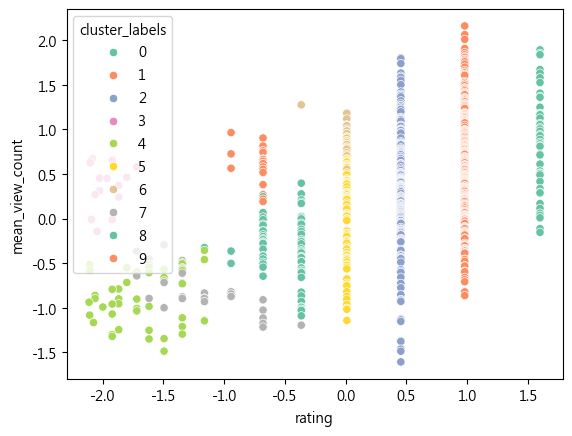

In [543]:
sns.scatterplot(x = df_clustered['rating'], y = df_clustered['mean_view_count'], hue=df_clustered['cluster_labels'], palette='Set2')

In [544]:
target_title = "葬送的芙莉蓮"
top_k = 10

if target_title not in features.index:
    raise ValueError(f"標題錯誤: {target_title}")

target_vec = features.loc[target_title]
dist = ((features - target_vec) ** 2).sum(axis=1).pow(0.5)
dist = dist.drop(index=target_title).sort_values()

print(f"與《{target_title}》最相似的動畫:")
for i, (idx, d) in enumerate(dist.head(top_k).items(), 1):
    print(f"  第 {i}: {idx}, 距離: {d:.4f}")

與《葬送的芙莉蓮》最相似的動畫:
  第 1: 葬送的芙莉蓮 第二季, 距離: 0.7623
  第 2: 無職轉生，到了異世界就拿出真本事, 距離: 1.1769
  第 3: Dr.STONE 新石紀, 距離: 1.2078
  第 4: 為美好的世界獻上祝福！3, 距離: 1.2159
  第 5: 無職轉生～到了異世界就拿出真本事 第二季, 距離: 1.2519
  第 6: 嘆氣的亡靈想隱退, 距離: 1.2598
  第 7: Silent Witch 沉默魔女的祕密, 距離: 1.2600
  第 8: OVERLORD 第二季, 距離: 1.2781
  第 9: 轉生為第七王子，隨心所欲的魔法學習之路, 距離: 1.2866
  第 10: 為美好的世界獻上祝福！, 距離: 1.2906


In [545]:
from sklearn.metrics.pairwise import cosine_similarity

target_title = "歲月流逝飯菜依舊美味"
top_k = 5
# 1. 檢查目標是否存在
if target_title not in features.index:
    raise ValueError(f"標題錯誤: {target_title}")

# 2. 提取目標向量並轉換成 2D 陣列 (sklearn 要求格式)
target_vec = features.loc[target_title].values.reshape(1, -1)

# 3. 計算餘弦相似度
similarities = cosine_similarity(features, target_vec).flatten()
dist_series = pd.Series(similarities, index=features.index)

# 4. 計算「餘弦距離」(1 - 相似度)
dist = (1 - dist_series).drop(index=target_title).sort_values()

# 5. 印出結果
print(f"《{target_title}》屬於第 {df_clustered.loc[target_title, 'cluster_labels']} 群的動畫")
print(f" 與其最相似的動畫 (餘弦距離):")
for i, (idx, d) in enumerate(dist.head(top_k).items(), 1):
    print(f"  第 {i}: {idx}, 距離: {d:.4f}")

《歲月流逝飯菜依舊美味》屬於第 0 群的動畫
 與其最相似的動畫 (餘弦距離):
  第 1: GRAND BLUE 碧藍之海 2, 距離: 0.0642
  第 2: GRAND BLUE 碧藍之海, 距離: 0.0668
  第 3: 青春豬頭少年不會夢到聖誕服女郎, 距離: 0.0915
  第 4: 搖曳露營△, 距離: 0.0935
  第 5: 堀與宮村 -piece-, 距離: 0.1037


###

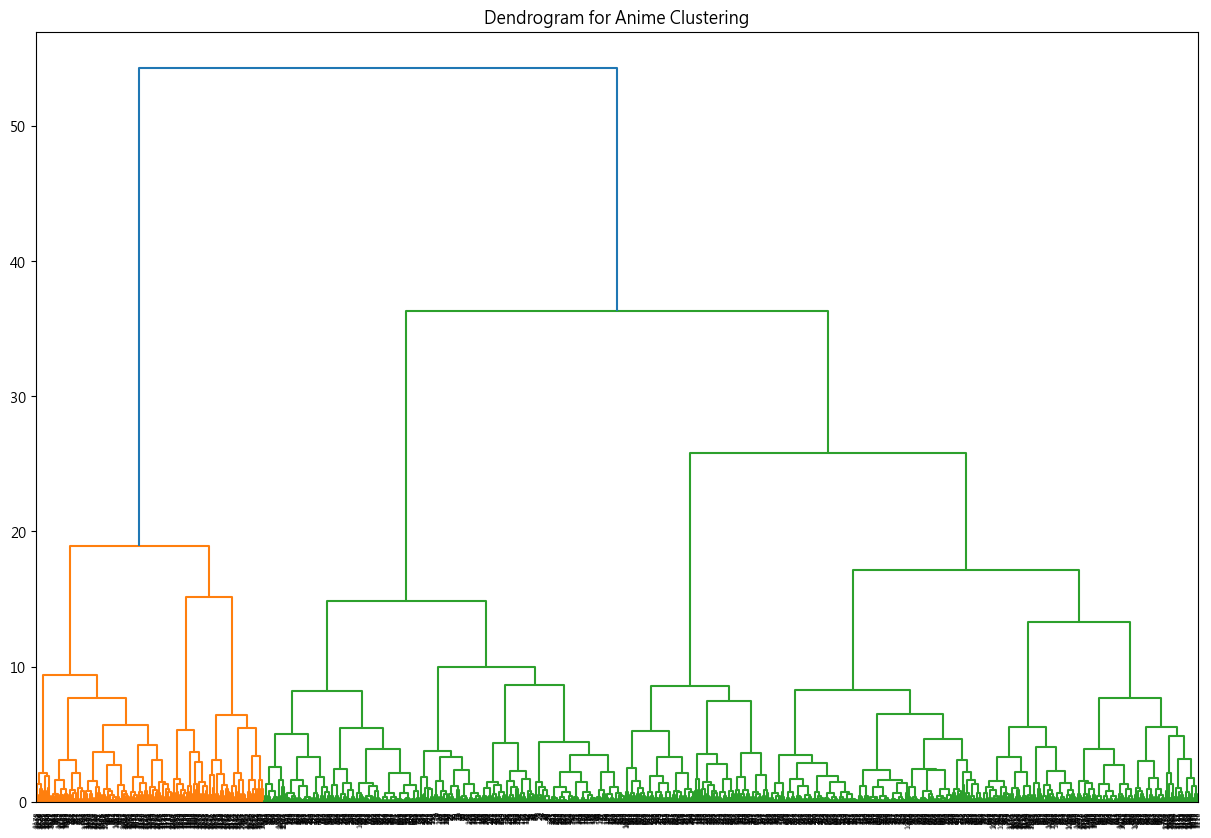

In [546]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# 1. 繪製樹狀圖，幫助決定要分幾群
plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(sch.linkage(X_pca, method='ward'))
plt.title('Dendrogram for Anime Clustering')
plt.show()

In [548]:
# 2. 執行分群 (假設看了樹狀圖後決定分 9 群)
hc = AgglomerativeClustering(n_clusters=9, metric='euclidean', linkage='ward')
cluster_labels_hc = hc.fit_predict(X_pca)

# X_pca 是 numpy array，先轉成 DataFrame 才能新增欄位
df_hc = pd.DataFrame(X_pca, index=df_final.index)
df_hc['hc_cluster'] = cluster_labels_hc
df_hc.head()

,0,1,2,hc_cluster
title,,,,
鬼滅之刃 竈門炭治郎 立志篇,-2.574639,-0.356747,0.717298,0
鬼滅之刃 遊郭篇,-2.924355,-0.565847,0.156010,0
咒術迴戰,-2.335084,-0.173825,0.769349,0
輝夜姬想讓人告白～天才們的戀愛頭腦戰～,-2.284321,-0.080960,0.620710,0
輝夜姬想讓人告白～天才們的戀愛頭腦戰～ 第二季,-2.936566,0.272907,0.208999,0
